In [1]:
# ============================================================
# H1 - CTAS TRIAGE LEVEL vs REPORTED MEDIAN ED LENGTH OF STAY
# ============================================================
# Research question : Does reported median ED LOS differ across CTAS triage levels?
# Null hypothesis   : Median LOS is equal across all CTAS triage levels.
# Alternative       : At least one CTAS triage level differs in median LOS.
# Method            : Frequency-weighted Kruskal-Wallis H test with Dunn post-hoc
#
# Rows are aggregates: ed_visits is a frequency weight, not a covariate.
#
# The test itself is NOT reimplemented here. It is imported from
# backend.analytics.statistics.weighted, the same engine the API serves, so this
# notebook and the production endpoint cannot report different numbers.

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 150)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Resolve the project root so the notebook runs from any working directory.
PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "backend").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

RAW_DIR = PROJECT_ROOT / "data" / "Explorer Dataset"
CLEAN_DIR = RAW_DIR / "cleaned"
WORKBOOK = PROJECT_ROOT / "data" / "cleaned dataset" / "Explanatory_and_Predictive_ED_Analytics_Dataset.xlsx"

ALPHA = 0.05

print("Project root :", PROJECT_ROOT)
print("Alpha        :", ALPHA)

Project root : C:\Users\amitd\Downloads\Desktoppp\UNF\UNF Assignment _ Notes_Class Practise\Term 5\Capstone\Github\Capstone_Project-DAMO-6994-
Alpha        : 0.05


In [3]:
# Prefer the cleaned copy written by data/Explorer Dataset/Explorer_Dataset_Cleaning.ipynb.
SOURCE = CLEAN_DIR / "CTAS_Triage.csv"

if not SOURCE.exists():
    SOURCE = RAW_DIR / "CTAS_Triage.csv"

df = pd.read_csv(SOURCE)

print("Source file :", SOURCE.relative_to(PROJECT_ROOT))
print("Shape       :", df.shape)
print("Cleaned copy:", SOURCE.parent == CLEAN_DIR)

Source file : data\Explorer Dataset\CTAS_Triage.csv
Shape       : (912, 10)
Cleaned copy: False


In [4]:
print("FIRST 10 ROWS")
print("-" * 80)

display(df.head(10))

FIRST 10 ROWS
--------------------------------------------------------------------------------


,fiscal_year,fiscal_year_start,sex,triage_level,ctas_urgency_score,age_group,population_category,ed_visits,median_los_minutes,median_los_hours
0,2021-2022,2021,Female,CTAS I - Resuscitation,1,0-19,Pediatric & Youth,10332,240,4.0
1,2021-2022,2021,Female,CTAS I - Resuscitation,1,20-44,Young Adult,11051,330,5.5
2,2021-2022,2021,Female,CTAS I - Resuscitation,1,45-64,Middle Adult,11653,324,5.4
3,2021-2022,2021,Female,CTAS I - Resuscitation,1,65+,Older Adult,25787,414,6.9
4,2021-2022,2021,Male,CTAS I - Resuscitation,1,0-19,Pediatric & Youth,12409,228,3.8
5,2021-2022,2021,Male,CTAS I - Resuscitation,1,20-44,Young Adult,18848,336,5.6
6,2021-2022,2021,Male,CTAS I - Resuscitation,1,45-64,Middle Adult,20762,300,5.0
7,2021-2022,2021,Male,CTAS I - Resuscitation,1,65+,Older Adult,30338,360,6.0
8,2021-2022,2021,Female,CTAS II - Emergent,2,0-19,Pediatric & Youth,208386,228,3.8
9,2021-2022,2021,Female,CTAS II - Emergent,2,20-44,Young Adult,416879,282,4.7


In [5]:
print("COLUMN NAMES AND TYPES")
print("-" * 80)

display(pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Missing": [int(df[c].isna().sum()) for c in df.columns],
}))

COLUMN NAMES AND TYPES
--------------------------------------------------------------------------------


,Column,Data_Type,Missing
0,fiscal_year,str,0
1,fiscal_year_start,int64,0
2,sex,str,0
3,triage_level,str,0
4,ctas_urgency_score,int64,0
5,age_group,str,0
6,population_category,str,0
7,ed_visits,int64,0
8,median_los_minutes,int64,0
9,median_los_hours,float64,0


In [6]:
print("DATA QUALITY CHECKS")
print("-" * 80)

print(f"Rows              : {len(df):,}")
print(f"Duplicate rows    : {df.duplicated().sum():,}")
print(f"Total missing     : {df.isna().sum().sum():,}")

if "ed_visits" in df.columns:
    print(f"ED visits <= 0    : {(df['ed_visits'] <= 0).sum():,}")
    print(f"Total ED visits   : {df['ed_visits'].sum():,.0f}")

if "median_los_minutes" in df.columns:
    print(f"LOS < 0           : {(df['median_los_minutes'] < 0).sum():,}")

DATA QUALITY CHECKS
--------------------------------------------------------------------------------
Rows              : 912
Duplicate rows    : 0
Total missing     : 0
ED visits <= 0    : 0
Total ED visits   : 175,762,944
LOS < 0           : 0


In [7]:
from backend.analytics.statistics.weighted import (
    weighted_dunn_post_hoc,
    weighted_kruskal_wallis,
    weighted_mean,
    weighted_median,
)

print("Weighted engine imported from backend.analytics.statistics.weighted")

Weighted engine imported from backend.analytics.statistics.weighted


In [8]:
# Unknown is a reporting artefact, not a triage decision, so it cannot take part in
# an acuity-ordered comparison.
VALID_CTAS_LEVELS = [
    "CTAS I - Resuscitation",
    "CTAS II - Emergent",
    "CTAS III - Urgent",
    "Less urgent",
    "Non-urgent",
]

h1_df = df[df["triage_level"].isin(VALID_CTAS_LEVELS)].copy()
h1_df = h1_df.dropna(subset=["triage_level", "ed_visits", "median_los_minutes"])
h1_df = h1_df[(h1_df["ed_visits"] > 0) & (h1_df["median_los_minutes"] >= 0)]

print("H1 ANALYSIS DATASET")
print("=" * 80)
print(f"Original records        : {len(df):,}")
print(f"Records after filtering : {len(h1_df):,}")
print(f"Records removed         : {len(df) - len(h1_df):,}")
print()

for level in VALID_CTAS_LEVELS:
    n = (h1_df["triage_level"] == level).sum()
    v = h1_df.loc[h1_df["triage_level"] == level, "ed_visits"].sum()
    print(f"  {level:24} {n:>4,} records   {v:>14,.0f} visits")

excluded = sorted(set(df["triage_level"].dropna()) - set(VALID_CTAS_LEVELS))
print()
print("Excluded categories:", excluded)

H1 ANALYSIS DATASET
Original records        : 912
Records after filtering : 760
Records removed         : 152

  CTAS I - Resuscitation    152 records        1,286,555 visits
  CTAS II - Emergent        152 records       26,742,361 visits
  CTAS III - Urgent         152 records       72,100,128 visits
  Less urgent               152 records       58,990,020 visits
  Non-urgent                152 records       15,088,331 visits

Excluded categories: ['Unknown']


In [9]:
print("WEIGHT VALIDATION")
print("=" * 80)

weights = h1_df["ed_visits"]

print("dtype                  :", weights.dtype)
print("non-integer weights    :", int((weights % 1 != 0).sum()))
print("minimum                :", f"{weights.min():,.0f}")
print("maximum                :", f"{weights.max():,.0f}")
print("total frequency weight :", f"{weights.sum():,.0f}")

WEIGHT VALIDATION
dtype                  : int64
non-integer weights    : 0
minimum                : 1,254
maximum                : 1,165,671
total frequency weight : 174,207,395


In [10]:
groups, names, wts = [], [], []

for level in VALID_CTAS_LEVELS:
    sub = h1_df[h1_df["triage_level"] == level]
    if sub.empty:
        continue
    groups.append(sub["median_los_minutes"].tolist())
    wts.append(sub["ed_visits"].tolist())
    names.append(level)

h1_summary = pd.DataFrame([
    {
        "triage_level": n,
        "records": len(g),
        "total_ed_visits": int(sum(w)),
        "weighted_mean_los_minutes": round(weighted_mean(g, w), 2),
        "weighted_median_los_minutes": round(weighted_median(g, w), 2),
        "minimum_los_minutes": min(g),
        "maximum_los_minutes": max(g),
    }
    for n, g, w in zip(names, groups, wts)
])

display(h1_summary)

,triage_level,records,total_ed_visits,weighted_mean_los_minutes,weighted_median_los_minutes,minimum_los_minutes,maximum_los_minutes
0,CTAS I - Resuscitation,152,1286555,281.65,276.0,135,414
1,CTAS II - Emergent,152,26742361,291.01,288.0,167,420
2,CTAS III - Urgent,152,72100128,212.68,204.0,130,348
3,Less urgent,152,58990020,122.54,114.0,90,228
4,Non-urgent,152,15088331,86.76,80.0,65,126


In [11]:
h1_result = weighted_kruskal_wallis(groups, names, wts)

print("H1 - WEIGHTED KRUSKAL-WALLIS TEST")
print("-" * 80)
print(f"Test statistic (H)     : {h1_result['h_statistic']:.6f}")
print(f"Degrees of freedom     : {h1_result['degrees_of_freedom']}")
print(f"P-value                : {h1_result['p_value']:.10f}")
print(f"Total frequency weight : {h1_result['weighted_n']:,}")
print(f"Tie correction         : {h1_result['tie_correction']:.10f}")

H1 - WEIGHTED KRUSKAL-WALLIS TEST
--------------------------------------------------------------------------------
Test statistic (H)     : 126319368.243397
Degrees of freedom     : 4
P-value                : 0.0000000000
Total frequency weight : 174,207,395
Tie correction         : 0.9995640491


In [12]:
# The tie correction is bounded above by 1 because it is 1 - sum(t^3 - t) / (N^3 - N)
# with every t >= 1. A value above 1 indicates integer overflow in the tie sum, which
# is why the engine accumulates it in pure-Python arbitrary-precision integers.

assert 0 < h1_result["tie_correction"] <= 1.0, "tie correction out of bounds"

print("Tie correction is a valid proportion:", h1_result["tie_correction"])
print()
print(f"Ties are material here: LOS is reported in whole minutes across")
print(f"{h1_result['weighted_n']:,} weighted observations.")

Tie correction is a valid proportion: 0.9995640491436388

Ties are material here: LOS is reported in whole minutes across
174,207,395 weighted observations.


In [13]:
p_value = h1_result["p_value"]

print("=" * 80)
print("H1 HYPOTHESIS DECISION")
print("=" * 80)
print("Significance level (alpha):", ALPHA)
print(f"P-value: {p_value:.10f}")
print()

if p_value < ALPHA:
    print("Decision: REJECT H0")
    print()
    print("Conclusion:")
    print("There is statistically significant evidence that reported median ED length")
    print("of stay differs across CTAS triage levels in the aggregate NACRS data.")
else:
    print("Decision: FAIL TO REJECT H0")
    print()
    print("Conclusion:")
    print("There is insufficient statistical evidence to conclude that reported median")
    print("ED length of stay differs across CTAS triage levels.")

H1 HYPOTHESIS DECISION
Significance level (alpha): 0.05
P-value: 0.0000000000

Decision: REJECT H0

Conclusion:
There is statistically significant evidence that reported median ED length
of stay differs across CTAS triage levels in the aggregate NACRS data.


In [14]:
epsilon_squared = h1_result["epsilon_squared"]

print("H1 EFFECT SIZE")
print("-" * 80)
print(f"Epsilon squared (eps^2): {epsilon_squared:.10f}")
print()

if epsilon_squared < 0.01:
    band = "Negligible"
elif epsilon_squared < 0.06:
    band = "Small"
elif epsilon_squared < 0.14:
    band = "Medium"
else:
    band = "Large"

print(f"Magnitude: {band}")
print()
print("eps^2 is the proportion of rank variance explained by CTAS grouping.")
print("With a weighted N this large, p-values are effectively guaranteed to be")
print("small, so the effect size carries the substantive interpretation.")

H1 EFFECT SIZE
--------------------------------------------------------------------------------
Epsilon squared (eps^2): 0.7251091027

Magnitude: Large

eps^2 is the proportion of rank variance explained by CTAS grouping.
With a weighted N this large, p-values are effectively guaranteed to be
small, so the effect size carries the substantive interpretation.


In [15]:
dunn = weighted_dunn_post_hoc(groups, names, wts, alpha=ALPHA)

dunn_table = pd.DataFrame(dunn)[
    ["group_a", "group_b", "z_score", "p_raw", "p_adj_bonferroni", "significant"]
]

print("H1 - DUNN POST-HOC (BONFERRONI ADJUSTED)")
print("-" * 80)
print(f"Comparisons: {len(dunn)}   Significant: {int(dunn_table['significant'].sum())}")
print()

display(dunn_table)

H1 - DUNN POST-HOC (BONFERRONI ADJUSTED)
--------------------------------------------------------------------------------
Comparisons: 10   Significant: 10



,group_a,group_b,z_score,p_raw,p_adj_bonferroni,significant
0,CTAS I - Resuscitation,CTAS II - Emergent,20.3895,2.074119e-92,2.074119e-91,True
1,CTAS I - Resuscitation,CTAS III - Urgent,715.5051,0.000000e+00,0.000000e+00,True
2,CTAS I - Resuscitation,Less urgent,2191.1859,0.000000e+00,0.000000e+00,True
3,CTAS I - Resuscitation,Non-urgent,2814.7839,0.000000e+00,0.000000e+00,True
4,CTAS II - Emergent,CTAS III - Urgent,2892.1154,0.000000e+00,0.000000e+00,True
5,CTAS II - Emergent,Less urgent,8455.5232,0.000000e+00,0.000000e+00,True
6,CTAS II - Emergent,Non-urgent,8086.3585,0.000000e+00,0.000000e+00,True
7,CTAS III - Urgent,Less urgent,7497.9817,0.000000e+00,0.000000e+00,True
8,CTAS III - Urgent,Non-urgent,6883.8350,0.000000e+00,0.000000e+00,True
9,Less urgent,Non-urgent,2192.3071,0.000000e+00,0.000000e+00,True


In [16]:
h1_result_table = pd.DataFrame({
    "Hypothesis": ["H1"],
    "Research_Question": ["Does reported median ED LOS differ across CTAS triage levels?"],
    "Test": ["Weighted Kruskal-Wallis"],
    "H_Statistic": [h1_result["h_statistic"]],
    "Degrees_of_Freedom": [h1_result["degrees_of_freedom"]],
    "Weighted_N": [h1_result["weighted_n"]],
    "P_Value": [p_value],
    "Epsilon_Squared": [epsilon_squared],
    "Alpha": [ALPHA],
    "Decision": ["Reject H0" if p_value < ALPHA else "Fail to Reject H0"],
})

display(h1_result_table)

,Hypothesis,Research_Question,Test,H_Statistic,Degrees_of_Freedom,Weighted_N,P_Value,Epsilon_Squared,Alpha,Decision
0,H1,Does reported median ED LOS differ across CTAS...,Weighted Kruskal-Wallis,1.263194e+08,4,174207395,0.0,0.725109,0.05,Reject H0


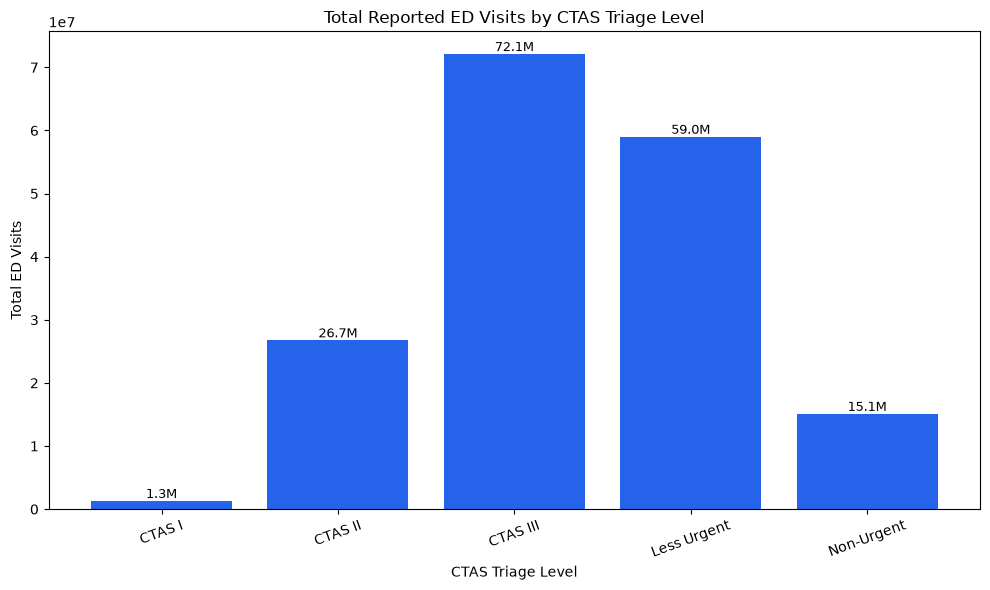

In [17]:
CTAS_SHORT = {
    "CTAS I - Resuscitation": "CTAS I",
    "CTAS II - Emergent": "CTAS II",
    "CTAS III - Urgent": "CTAS III",
    "Less urgent": "Less Urgent",
    "Non-urgent": "Non-Urgent",
}

labels = [CTAS_SHORT.get(n, n) for n in names]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(labels, h1_summary["total_ed_visits"], color="#2563EB")
ax.set_xlabel("CTAS Triage Level")
ax.set_ylabel("Total ED Visits")
ax.set_title("Total Reported ED Visits by CTAS Triage Level")

for bar, value in zip(bars, h1_summary["total_ed_visits"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{value/1e6:.1f}M", ha="center", va="bottom", fontsize=9)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

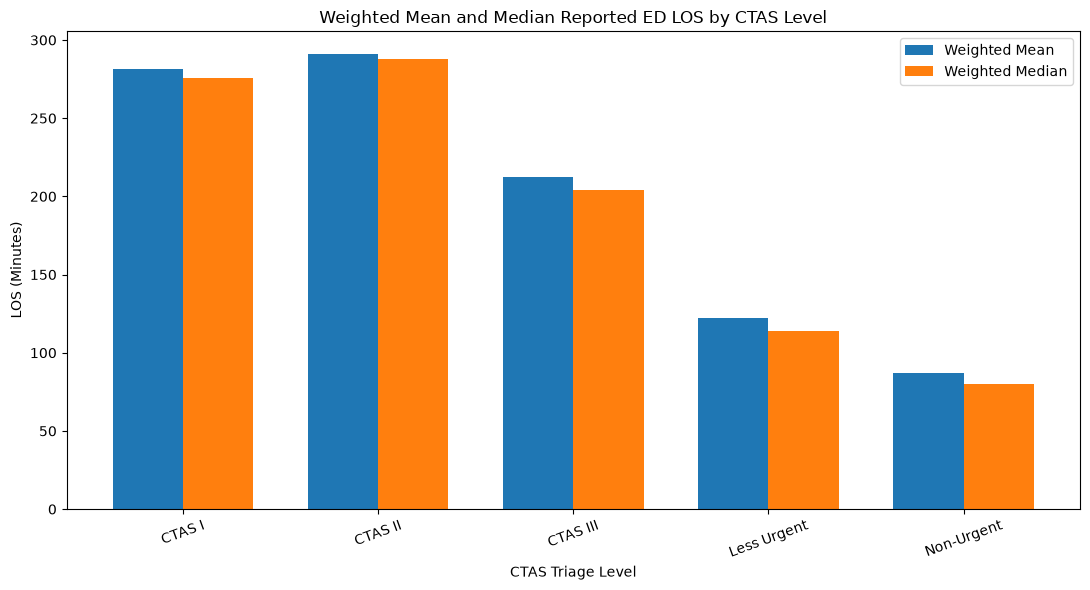

In [18]:
x = np.arange(len(labels))
width = 0.36

fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(x - width / 2, h1_summary["weighted_mean_los_minutes"], width, label="Weighted Mean")
ax.bar(x + width / 2, h1_summary["weighted_median_los_minutes"], width, label="Weighted Median")

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20)
ax.set_xlabel("CTAS Triage Level")
ax.set_ylabel("LOS (Minutes)")
ax.set_title("Weighted Mean and Median Reported ED LOS by CTAS Level")
ax.legend()

plt.tight_layout()
plt.show()

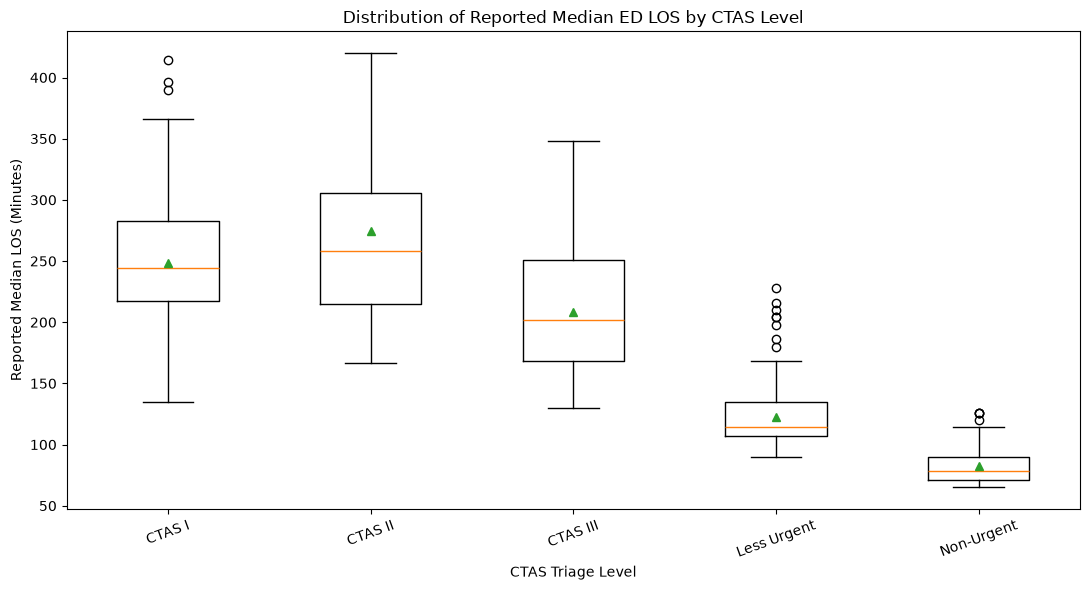

In [19]:
box_data = [np.array(g) for g in groups]

fig, ax = plt.subplots(figsize=(11, 6))

ax.boxplot(box_data, tick_labels=labels, showmeans=True)
ax.set_xlabel("CTAS Triage Level")
ax.set_ylabel("Reported Median LOS (Minutes)")
ax.set_title("Distribution of Reported Median ED LOS by CTAS Level")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

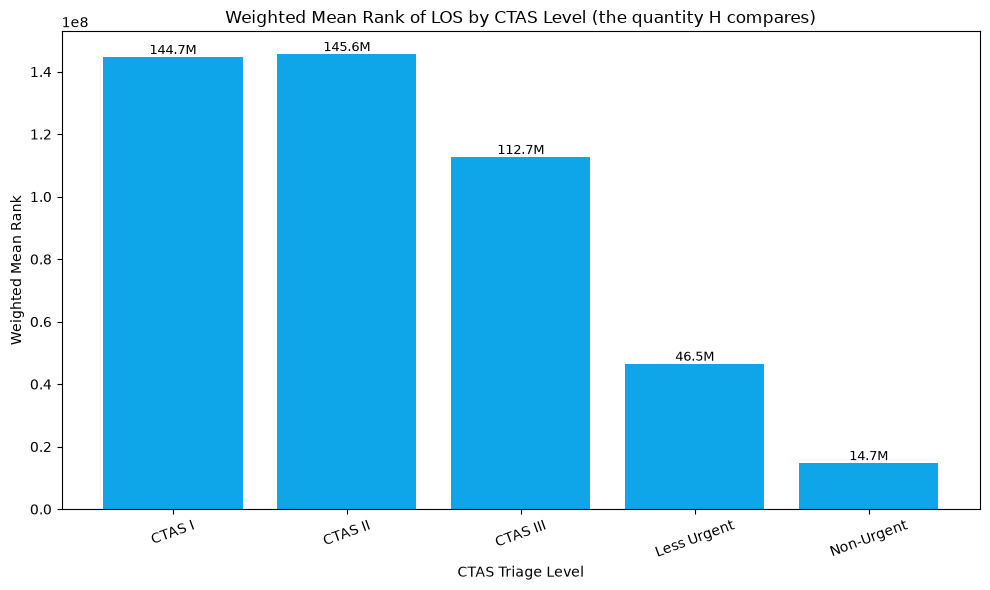

In [20]:
# Mean rank per group is what the Kruskal-Wallis statistic actually compares.
mean_ranks = [g["mean_rank"] for g in h1_result["group_statistics"]]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(labels, mean_ranks, color="#0EA5E9")
ax.set_xlabel("CTAS Triage Level")
ax.set_ylabel("Weighted Mean Rank")
ax.set_title("Weighted Mean Rank of LOS by CTAS Level (the quantity H compares)")

for bar, value in zip(bars, mean_ranks):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{value/1e6:.1f}M", ha="center", va="bottom", fontsize=9)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

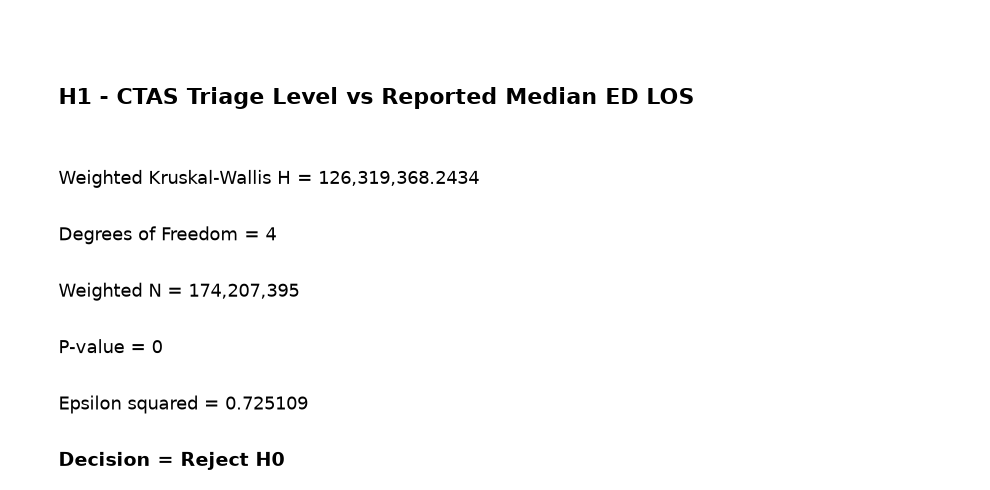

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis("off")

decision = "Reject H0" if p_value < ALPHA else "Fail to Reject H0"

ax.text(0.05, 0.80, "H1 - CTAS Triage Level vs Reported Median ED LOS",
        fontsize=16, fontweight="bold")
ax.text(0.05, 0.63, f"Weighted Kruskal-Wallis H = {h1_result['h_statistic']:,.4f}", fontsize=13)
ax.text(0.05, 0.51, f"Degrees of Freedom = {h1_result['degrees_of_freedom']}", fontsize=13)
ax.text(0.05, 0.39, f"Weighted N = {h1_result['weighted_n']:,}", fontsize=13)
ax.text(0.05, 0.27, f"P-value = {p_value:.6g}", fontsize=13)
ax.text(0.05, 0.15, f"Epsilon squared = {epsilon_squared:.6f}", fontsize=13)
ax.text(0.05, 0.03, f"Decision = {decision}", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

In [22]:
# Parity check: the production endpoint must return the same numbers.
from backend.analytics.hypothesis_testing import run_h1_test

api = run_h1_test()

print("NOTEBOOK vs PRODUCTION ENGINE")
print("=" * 80)
print(f"{'metric':22} {'notebook':>22} {'backend':>22}")
print(f"{'H':22} {h1_result['h_statistic']:>22,.4f} {api['h_statistic']:>22,.4f}")
print(f"{'weighted N':22} {h1_result['weighted_n']:>22,} {api['weighted_n']:>22,}")
print(f"{'epsilon squared':22} {epsilon_squared:>22.6f} {api['epsilon_squared']:>22.6f}")
print(f"{'decision':22} {decision:>22} {api['decision']:>22}")

NOTEBOOK vs PRODUCTION ENGINE
metric                               notebook                backend
H                            126,319,368.2434       126,319,368.2434
weighted N                        174,207,395            174,207,395
epsilon squared                      0.725109               0.725109
decision                            Reject H0              Reject H₀
